# 01 · Bring your own model

Any deterministic model works with GPU if it implements the `BaseForwardModel` contract:

- `n_parameters(n_features) -> int`
- `forward(X, params) -> [n_samples, n_particles]` (vectorised over particles)

The optimiser owns the parameters; the model just evaluates them.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from foresight_gpu import GPURegressor
from foresight_gpu.models import BaseForwardModel
from foresight_gpu.utils import plot_qq

### A line in a dozen lines

The simplest model there is: `y = a·x + b`, two parameters. Each particle is one candidate
line, and `forward` evaluates all of them at once.

The model owns its units: `forward` must return values directly comparable with `y`. Here
`x` lies in [0, 10] and the slope and intercept are well inside the default parameter
bounds (±30), so no scaling is needed. `03_extra_diagnostics` shows the `Pipeline` route
when it is.

In [ ]:
class LineModel(BaseForwardModel):
    def n_parameters(self, n_features):
        return 2                                  # slope, intercept

    def forward(self, X, params):
        params = np.atleast_2d(params)            # [n_particles, 2]
        slope, intercept = params[:, 0], params[:, 1]
        return X[:, :1] * slope[None, :] + intercept[None, :]  # [n_samples, n_particles]

### Drop it into `GPURegressor`

Synthetic data with an upward trend, `y = 2x + 3` plus noise. The bands are plotted against
`x`, so the fitted slope is visible directly.

true line:   y = 2.00x + 3.00
median band: y = 2.03x + 1.33
R2 = 0.856


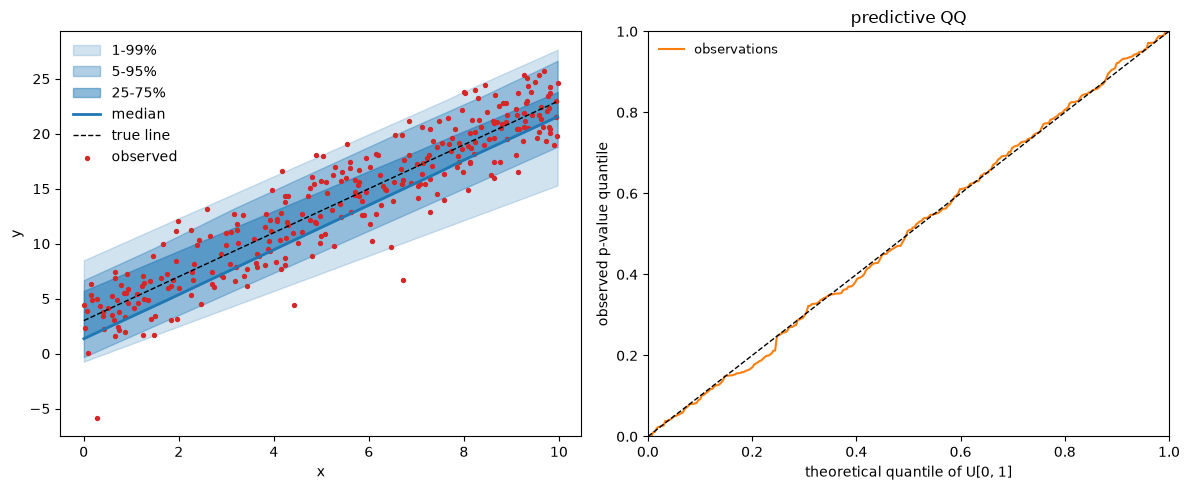

In [ ]:
rng = np.random.default_rng(0)
x = np.sort(rng.uniform(0, 10, 300))
true_slope, true_intercept = 2.0, 3.0
y = true_slope * x + true_intercept + 2.5 * rng.standard_normal(x.size)
X = x[:, None]

gpu = GPURegressor(model=LineModel(), metric='mae', population=300,
                   n_iter=80, random_state=0).fit(X, y)

quantiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
bands = gpu.predict_quantiles(X, quantiles=quantiles)
slope, intercept = np.polyfit(x, bands[:, 2], 1)
print(f'true line:   y = {true_slope:.2f}x + {true_intercept:.2f}')
print(f'median band: y = {slope:.2f}x + {intercept:.2f}')
print('R2 =', round(gpu.score(X, y), 3))

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5))
ax0.fill_between(x, bands[:, 0], bands[:, 6], color='C0', alpha=0.2, label='1-99%')
ax0.fill_between(x, bands[:, 1], bands[:, 5], color='C0', alpha=0.35, label='5-95%')
ax0.fill_between(x, bands[:, 2], bands[:, 4], color='C0', alpha=0.5, label='25-75%')
ax0.plot(x, bands[:, 2], color='C0', lw=2, label='median')
ax0.plot(x, true_slope * x + true_intercept, 'k--', lw=1, label='true line')
ax0.scatter(x, y, s=8, color='C3', label='observed')
ax0.set_xlabel('x')
ax0.set_ylabel('y')
ax0.legend(frameon=False)
plot_qq(gpu.predictive_pvalues(X, y), ax=ax1)
ax1.set_title('predictive QQ')
fig.tight_layout()

That is all it takes. The built-in `MLPModel` and the hydrological `GR4JModel` follow the same
contract — see `foresight_gpu/models/` and the next notebook.

**Notebooks:** `00_quickstart` · `01_custom_model` · `02_gr4j` · `03_extra_diagnostics` ·
`04_uncertainty_experiments`